# 🧬 Lab 1: 유전 알고리즘(GA) 원리 이해 (30분)

## 학습 목표
1. 유전 알고리즘의 핵심 연산(선택, 교차, 변이)을 **직접 코딩**하며 이해한다
2. 세대가 반복될수록 해(Solution)가 **진화**하는 과정을 관찰한다
3. AI 학습의 본질 = "좋은 답을 점점 더 잘 찾아가는 과정"임을 체험한다

## 비유: 자연선택과 진화
| 생물학 | 유전 알고리즘 |
|--------|--------------|
| 개체 | 하나의 후보 해 (solution) |
| 유전자 | 해를 구성하는 파라미터 (숫자 배열) |
| 적합도 | 얼마나 좋은 해인지 점수 |
| 자연선택 | 점수 높은 해를 부모로 선택 |
| 교배 | 두 부모의 파라미터를 섞기 |
| 돌연변이 | 파라미터에 랜덤 변화 |

> **핵심**: 정답을 직접 알려주지 않아도, "좋은지 나쁜지"만 평가하면 스스로 정답을 찾아간다!


## 1단계: 환경 설정

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 재현성을 위한 시드 고정
np.random.seed(42)
print("✅ 환경 설정 완료!")


✅ 환경 설정 완료!


## 2단계: 문제 정의 — "비밀번호 맞추기 게임"

컴퓨터가 비밀번호 `[3, 1, 4, 1, 5, 9, 2, 6]`을 숨기고 있습니다.

우리는 이 비밀번호를 **모른 채로**, 유전 알고리즘만으로 찾아낼 것입니다.

단, 우리가 알 수 있는 건 딱 하나:
> **"내가 제출한 답이 정답에 얼마나 가까운지"** (= 적합도)


In [ ]:
# ============================================
# 비밀번호 (정답) — 우리는 이걸 모른다고 가정!
# ============================================
SECRET = np.array([3, 1, 4, 1, 5, 9, 2, 6])
PASSWORD_LEN = len(SECRET)

def fitness(individual):
    """
    적합도 함수: 정답과 얼마나 가까운지 측정
    - 각 자리의 차이를 합산 (작을수록 좋음)
    - 점수가 높을수록 좋게 변환 (max - 차이)
    """
    diff = np.sum(np.abs(individual - SECRET))
    max_possible_diff = PASSWORD_LEN * 9  # 최대 가능한 차이
    return max_possible_diff - diff  # 높을수록 좋음

# 테스트
test1 = np.array([0, 0, 0, 0, 0, 0, 0, 0])  # 완전 틀린 답
test2 = np.array([3, 1, 4, 1, 5, 9, 2, 6])  # 정답

print(f"완전 틀린 답 {test1} → 적합도: {fitness(test1)}")
print(f"정답        {test2} → 적합도: {fitness(test2)} (최대값!)")
print(f"\n적합도가 {PASSWORD_LEN * 9}이면 정답을 맞춘 것입니다.")


완전 틀린 답 [0 0 0 0 0 0 0 0] → 적합도: 41
정답        [3 1 4 1 5 9 2 6] → 적합도: 72 (최대값!)

적합도가 72이면 정답을 맞춘 것입니다.


## 3단계: 1세대 — 랜덤으로 시작

진화의 첫 단계: **완전히 랜덤한 개체들**을 만듭니다.

이 개체들은 대부분 형편없는 답이지만, 그 중에서도 "조금 덜 나쁜" 답이 있을 것입니다.


In [ ]:
# ============================================
# 인구 생성: 랜덤 개체 20개
# ============================================
POP_SIZE = 20

def create_population(size):
    """0~9 사이의 랜덤 숫자로 이루어진 개체를 생성"""
    return [np.random.randint(0, 10, PASSWORD_LEN) for _ in range(size)]

population = create_population(POP_SIZE)
scores = [fitness(ind) for ind in population]

print("=" * 55)
print("🧬 1세대 (랜덤 생성)")
print("=" * 55)
for i, (ind, score) in enumerate(zip(population, scores)):
    bar = "█" * (score // 3)
    print(f"  개체 {i+1:2d}: {ind} → 적합도: {score:3d} {bar}")

print(f"\n📊 최고 적합도: {max(scores)}")
print(f"📊 평균 적합도: {np.mean(scores):.1f}")
print(f"📊 정답까지 남은 거리: {PASSWORD_LEN * 9 - max(scores)}")


🧬 1세대 (랜덤 생성)
  개체  1: [6 3 7 4 6 9 2 6] → 적합도:  60 ████████████████████
  개체  2: [7 4 3 7 7 2 5 4] → 적합도:  44 ██████████████
  개체  3: [1 7 5 1 4 0 9 5] → 적합도:  45 ███████████████
  개체  4: [8 0 9 2 6 3 8 2] → 적합도:  43 ██████████████
  개체  5: [4 2 6 4 8 6 1 3] → 적합도:  55 ██████████████████
  개체  6: [8 1 9 8 9 4 1 3] → 적합도:  42 ██████████████
  개체  7: [6 7 2 0 3 1 7 3] → 적합도:  42 ██████████████
  개체  8: [1 5 5 9 3 5 1 9] → 적합도:  47 ███████████████
  개체  9: [1 9 3 7 6 8 7 4] → 적합도:  46 ███████████████
  개체 10: [1 4 7 9 8 8 0 8] → 적합도:  48 ████████████████
  개체 11: [6 8 7 0 7 7 2 0] → 적합도:  48 ████████████████
  개체 12: [7 2 2 0 4 9 6 9] → 적합도:  56 ██████████████████
  개체 13: [8 6 8 7 1 0 6 6] → 적합도:  35 ███████████
  개체 14: [7 4 2 7 5 2 0 2] → 적합도:  44 ██████████████
  개체 15: [4 2 0 4 9 6 6 8] → 적합도:  50 ████████████████
  개체 16: [9 9 2 6 0 3 3 4] → 적합도:  37 ████████████
  개체 17: [6 6 3 6 2 5 1 9] → 적합도:  47 ███████████████
  개체 18: [8 4 5 3 9 6 8 6] → 적합도:  48 ████████████████
  개체 19: [0

## 4단계: 선택 (Selection) — "우수한 개체를 부모로"

자연선택의 원리: **적합도가 높은 개체일수록 자식을 낳을 확률이 높다**

여기서는 **토너먼트 선택**을 사용합니다:
1. 랜덤으로 3개 후보를 뽑는다
2. 그 중 적합도가 가장 높은 걸 부모로 선택

> 🤔 **생각해보기**: 왜 "무조건 최고만" 뽑지 않고, 토너먼트를 할까요?


In [ ]:
# ============================================
# 선택 연산: 토너먼트 선택
# ============================================
def tournament_selection(population, scores, tournament_size=3):
    """
    토너먼트 선택:
    - "무조건 1등만 선택" → 다양성이 사라짐 → 지역 최적에 갇힘
    - 토너먼트 → 2등, 3등도 선택될 기회 → 다양성 유지
    """
    candidates = np.random.choice(len(population), tournament_size, replace=False)
    best_idx = candidates[np.argmax([scores[c] for c in candidates])]
    return population[best_idx].copy()

print("🏆 토너먼트 선택 시연")
print("=" * 50)
for i in range(5):
    parent = tournament_selection(population, scores)
    score = fitness(parent)
    print(f"  선택된 부모 {i+1}: {parent} → 적합도: {score}")

print(f"\n참고: 전체 평균 적합도는 {np.mean(scores):.1f}")
print("→ 선택된 부모들의 적합도가 평균보다 높은 경향!")


🏆 토너먼트 선택 시연
  선택된 부모 1: [0 0 8 8 3 8 2 6] → 적합도: 54
  선택된 부모 2: [6 6 3 6 2 5 1 9] → 적합도: 47
  선택된 부모 3: [6 6 3 6 2 5 1 9] → 적합도: 47
  선택된 부모 4: [4 2 6 4 8 6 1 3] → 적합도: 55
  선택된 부모 5: [4 2 0 4 9 6 6 8] → 적합도: 50

참고: 전체 평균 적합도는 46.4
→ 선택된 부모들의 적합도가 평균보다 높은 경향!


## 5단계: 교차 (Crossover) — "두 부모의 유전자를 섞기"

두 우수한 부모의 유전자를 절반씩 섞어 자식을 만듭니다.

```
부모 A: [3, 7, 4, 2, | 8, 1, 2, 9]
부모 B: [1, 1, 6, 1, | 5, 9, 0, 3]
                     ↑ 교차점
자식:   [3, 7, 4, 2, | 5, 9, 0, 3]  ← A의 앞부분 + B의 뒷부분
```


In [ ]:
# ============================================
# 교차 연산: 한 점 교차 (One-Point Crossover)
# ============================================
def crossover(parent_a, parent_b):
    point = np.random.randint(1, len(parent_a))
    child = np.empty_like(parent_a)
    child[:point] = parent_a[:point]
    child[point:] = parent_b[point:]
    return child, point

print("🔀 교차 연산 시연")
print("=" * 55)

parent_a = tournament_selection(population, scores)
parent_b = tournament_selection(population, scores)
child, point = crossover(parent_a, parent_b)

print(f"  부모 A: {parent_a}  (적합도: {fitness(parent_a)})")
print(f"  부모 B: {parent_b}  (적합도: {fitness(parent_b)})")
print(f"  교차점: {point}번째 위치")
print(f"  자식:   {child}  (적합도: {fitness(child)})")

better = 0
for _ in range(1000):
    a = tournament_selection(population, scores)
    b = tournament_selection(population, scores)
    c, _ = crossover(a, b)
    if fitness(c) > max(fitness(a), fitness(b)):
        better += 1
print(f"\n💡 1000번 교차 중 부모보다 좋은 자식: {better}번 ({better/10:.1f}%)")


🔀 교차 연산 시연
  부모 A: [1 4 7 9 8 8 0 8]  (적합도: 48)
  부모 B: [7 4 3 7 7 2 5 4]  (적합도: 44)
  교차점: 7번째 위치
  자식:   [1 4 7 9 8 8 0 4]  (적합도: 48)

💡 1000번 교차 중 부모보다 좋은 자식: 192번 (19.2%)


## 6단계: 변이 (Mutation) — "유전자에 돌연변이 발생"

교차만으로는 부모에게 없는 새로운 유전자를 만들 수 없습니다.

**변이**는 각 유전자에 일정 확률로 랜덤 변화를 줍니다.

> **변이율(mutation rate)**: 너무 높으면 → 랜덤 탐색과 같음. 너무 낮으면 → 새로운 해를 못 찾음.


In [ ]:
# ============================================
# 변이 연산
# ============================================
def mutate(individual, mutation_rate=0.15):
    mutated = individual.copy()
    for i in range(len(mutated)):
        if np.random.random() < mutation_rate:
            mutated[i] = np.random.randint(0, 10)
    return mutated

print("🎲 변이 연산 시연")
print("=" * 55)

original = tournament_selection(population, scores)
print(f"  원본:   {original}  (적합도: {fitness(original)})")

for rate in [0.05, 0.15, 0.30, 0.50]:
    mutated = mutate(original, rate)
    changed = np.sum(original != mutated)
    print(f"  변이({rate:.0%}): {mutated}  (적합도: {fitness(mutated)}, {changed}자리 변경)")


🎲 변이 연산 시연
  원본:   [4 2 6 4 8 6 1 3]  (적합도: 55)
  변이(5%): [4 2 6 4 8 6 1 3]  (적합도: 55, 0자리 변경)
  변이(15%): [4 2 1 4 6 6 1 3]  (적합도: 56, 2자리 변경)
  변이(30%): [0 4 6 3 8 6 1 3]  (적합도: 52, 3자리 변경)
  변이(50%): [3 3 8 4 7 0 8 3]  (적합도: 43, 6자리 변경)


## 7단계: 전체 GA 실행 — 진화 관찰! 🚀

모든 연산을 합쳐서 **세대를 반복**합니다:

```
[1세대] 랜덤 → [평가] → [선택] → [교차] → [변이] → [2세대] → ...
```


In [ ]:
# ============================================
# 유전 알고리즘 전체 실행
# ============================================
def run_ga(pop_size=20, generations=50, mutation_rate=0.15, verbose=True):
    best_history, avg_history = [], []
    best_individual, best_score = None, 0
    
    population = create_population(pop_size)
    
    for gen in range(generations):
        scores = [fitness(ind) for ind in population]
        gen_best_idx = np.argmax(scores)
        gen_best_score = scores[gen_best_idx]
        gen_avg_score = np.mean(scores)
        
        if gen_best_score > best_score:
            best_score = gen_best_score
            best_individual = population[gen_best_idx].copy()
        
        best_history.append(gen_best_score)
        avg_history.append(gen_avg_score)
        
        if verbose and (gen % 10 == 0 or gen_best_score == PASSWORD_LEN * 9):
            print(f"  세대 {gen+1:3d} | 최고: {gen_best_score:3d} | "
                  f"평균: {gen_avg_score:5.1f} | "
                  f"최고 개체: {population[gen_best_idx]}")
        
        if gen_best_score == PASSWORD_LEN * 9:
            if verbose:
                print(f"\n🎉 {gen+1}세대 만에 정답을 찾았습니다!")
            break
        
        new_population = [population[gen_best_idx].copy()]  # 엘리트 보존
        
        while len(new_population) < pop_size:
            parent_a = tournament_selection(population, scores)
            parent_b = tournament_selection(population, scores)
            child, _ = crossover(parent_a, parent_b)
            child = mutate(child, mutation_rate)
            new_population.append(child)
        
        population = new_population
    
    return best_history, avg_history, best_individual

print("=" * 60)
print("🧬 유전 알고리즘 실행 — 비밀번호를 찾아라!")
print(f"   비밀번호 길이: {PASSWORD_LEN}자리 | 인구: 20 | 변이율: 15%")
print("=" * 60)

np.random.seed(42)
best_hist, avg_hist, best_ind = run_ga()

print(f"\n최종 결과: {best_ind}")
print(f"실제 정답: {SECRET}")
print(f"일치 여부: {'✅ 완벽 일치!' if np.array_equal(best_ind, SECRET) else '❌ 아직 차이 있음'}")


🧬 유전 알고리즘 실행 — 비밀번호를 찾아라!
   비밀번호 길이: 8자리 | 인구: 20 | 변이율: 15%
  세대   1 | 최고:  60 | 평균:  46.4 | 최고 개체: [6 3 7 4 6 9 2 6]
  세대  11 | 최고:  68 | 평균:  62.7 | 최고 개체: [4 1 5 1 6 8 2 6]
  세대  21 | 최고:  71 | 평균:  65.5 | 최고 개체: [3 1 4 1 5 8 2 6]
  세대  31 | 최고:  71 | 평균:  66.0 | 최고 개체: [3 1 4 1 5 8 2 6]
  세대  41 | 최고:  71 | 평균:  64.8 | 최고 개체: [3 1 4 1 5 8 2 6]

최종 결과: [3 1 4 1 5 8 2 6]
실제 정답: [3 1 4 1 5 9 2 6]
일치 여부: ❌ 아직 차이 있음


## 8단계: 진화 과정 시각화

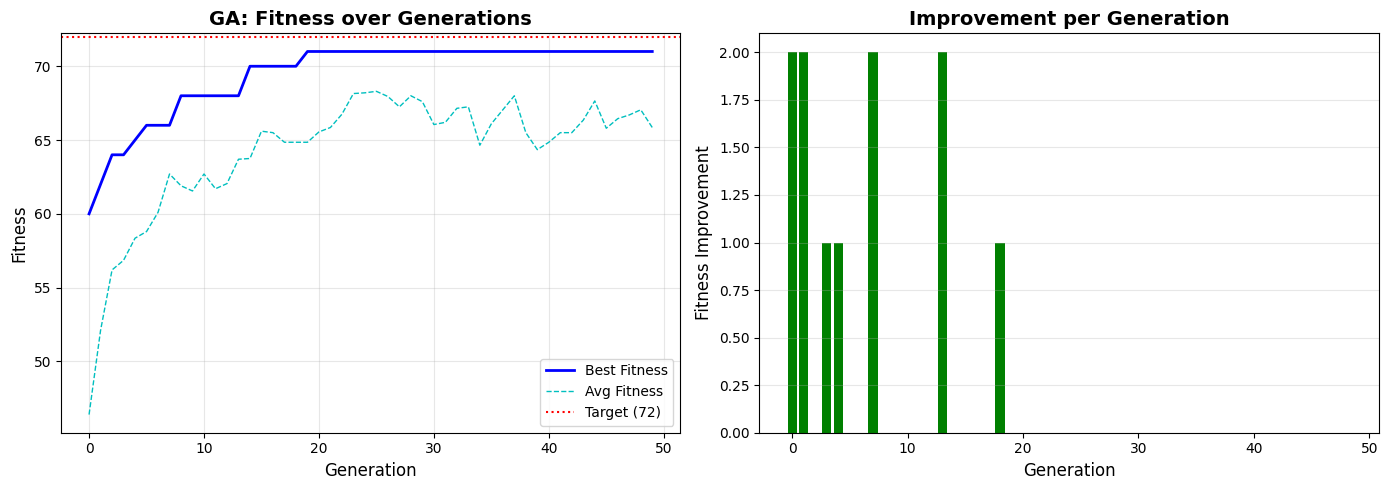


📊 관찰 포인트:
  1. 초기에 빠르게 향상 → 후반에 느려지는 패턴
  2. 평균이 최고를 따라 올라가는 현상
  3. 향상이 멈추는 '정체기' → 변이가 돌파구


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(best_hist, 'b-', linewidth=2, label='Best Fitness')
ax1.plot(avg_hist, 'c--', linewidth=1, label='Avg Fitness')
ax1.axhline(y=PASSWORD_LEN * 9, color='r', linestyle=':', label=f'Target ({PASSWORD_LEN * 9})')
ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Fitness', fontsize=12)
ax1.set_title('GA: Fitness over Generations', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
improvements = [best_hist[i] - best_hist[i-1] for i in range(1, len(best_hist))]
ax2.bar(range(len(improvements)), improvements, color=['green' if v > 0 else 'gray' for v in improvements])
ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Fitness Improvement', fontsize=12)
ax2.set_title('Improvement per Generation', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 관찰 포인트:")
print("  1. 초기에 빠르게 향상 → 후반에 느려지는 패턴")
print("  2. 평균이 최고를 따라 올라가는 현상")
print("  3. 향상이 멈추는 '정체기' → 변이가 돌파구")


## 🔬 직접 실험해보기!

| 실험 | 변경할 것 | 관찰 포인트 |
|------|----------|------------|
| A | `pop_size=5` (인구 축소) | 찾는 속도가 느려지나? |
| B | `pop_size=100` (인구 확대) | 빨라지나? 계산량은? |
| C | `mutation_rate=0.01` (변이 줄임) | 정체되나? |
| D | `mutation_rate=0.50` (변이 높임) | 오히려 느려지나? |


실험 조건: 인구=20, 변이율=0.15
------------------------------------------------------------
  세대   1 | 최고:  60 | 평균:  46.4 | 최고 개체: [6 3 7 4 6 9 2 6]
  세대  11 | 최고:  68 | 평균:  62.7 | 최고 개체: [4 1 5 1 6 8 2 6]
  세대  21 | 최고:  71 | 평균:  65.5 | 최고 개체: [3 1 4 1 5 8 2 6]
  세대  31 | 최고:  71 | 평균:  66.0 | 최고 개체: [3 1 4 1 5 8 2 6]
  세대  41 | 최고:  71 | 평균:  64.8 | 최고 개체: [3 1 4 1 5 8 2 6]
  세대  51 | 최고:  71 | 평균:  66.2 | 최고 개체: [3 1 4 1 5 8 2 6]
  세대  52 | 최고:  72 | 평균:  66.3 | 최고 개체: [3 1 4 1 5 9 2 6]

🎉 52세대 만에 정답을 찾았습니다!


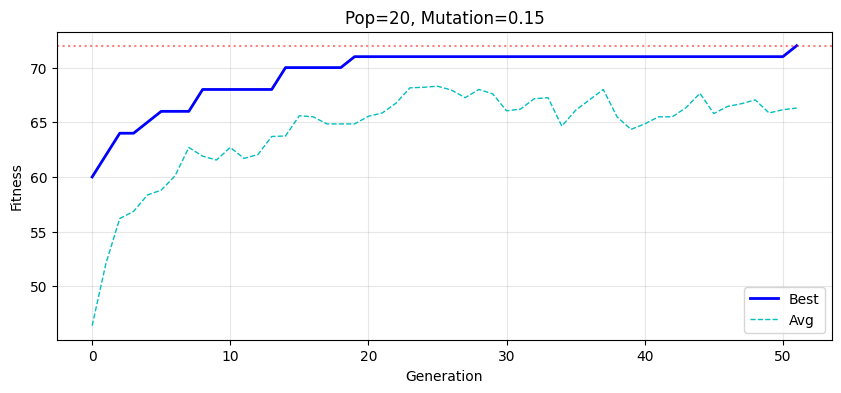

In [ ]:
# ============================================
# 🔬 실험: 파라미터를 바꿔보세요!
# ============================================

# ▼▼▼ 이 값들을 바꿔보세요 ▼▼▼
EXPERIMENT_POP_SIZE = 20       # 시도: 5, 10, 20, 50, 100
EXPERIMENT_MUTATION_RATE = 0.15  # 시도: 0.01, 0.05, 0.15, 0.30, 0.50
# ▲▲▲ 이 값들을 바꿔보세요 ▲▲▲

np.random.seed(42)
print(f"실험 조건: 인구={EXPERIMENT_POP_SIZE}, 변이율={EXPERIMENT_MUTATION_RATE}")
print("-" * 60)

b_hist, a_hist, result = run_ga(
    pop_size=EXPERIMENT_POP_SIZE,
    mutation_rate=EXPERIMENT_MUTATION_RATE,
    generations=100
)

plt.figure(figsize=(10, 4))
plt.plot(b_hist, 'b-', linewidth=2, label='Best')
plt.plot(a_hist, 'c--', linewidth=1, label='Avg')
plt.axhline(y=PASSWORD_LEN * 9, color='r', linestyle=':', alpha=0.5)
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title(f'Pop={EXPERIMENT_POP_SIZE}, Mutation={EXPERIMENT_MUTATION_RATE}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 📝 핵심 정리

| 연산 | 역할 | 생물학 비유 |
|------|------|------------|
| **선택** (Selection) | 좋은 해를 부모로 선택 | 자연선택, 적자생존 |
| **교차** (Crossover) | 두 부모의 특성을 섞음 | 유성생식 |
| **변이** (Mutation) | 랜덤 변화로 새로운 가능성 | 돌연변이 |

### GA의 특징
- ✅ 정답을 몰라도 적합도만 있으면 학습 가능
- ✅ 미분 불가능한 문제에도 적용 가능
- ✅ 여러 해를 동시에 탐색 → 지역 최적 탈출 가능
- ⚠️ 수렴 속도가 느릴 수 있음
- ⚠️ 하이퍼파라미터 조정 필요

> **다음**: Lab 2에서 GA를 **신경망 학습**에 적용하고, 다른 방법과 비교합니다!
